In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

import warnings 
warnings.filterwarnings("ignore")

df = pd.read_csv('../data/Preprocessed.csv')
df.head()

,Age,Number of Dependents,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,...,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check,Churn Label
0,78,0,34.023810,-118.156582,68701,0,1,0.00,8,39.65,...,0,1,0,0,0,0,1,0,0,1
1,74,1,34.044271,-118.185237,55668,1,8,48.85,17,80.65,...,0,0,0,1,0,0,1,1,0,1
2,71,3,34.108833,-118.229715,47534,0,18,11.33,52,95.45,...,1,1,1,1,0,0,1,0,0,1
3,78,1,33.936291,-118.332639,27778,1,25,19.76,12,98.50,...,1,1,0,1,0,0,1,0,0,1
4,80,1,33.972119,-118.020188,26265,1,37,6.33,14,76.50,...,0,0,0,1,0,0,1,0,0,1


In [9]:
X = df.drop('Churn Label', axis=1)
y = df['Churn Label']

In [10]:
X.shape, y.shape

((7043, 45), (7043,))

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

print("\nTraining Target Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True))

Training Set : (5634, 45)
Testing Set  : (1409, 45)

Training Target Distribution
Churn Label
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Target Distribution
Churn Label
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(8278, 45)
Churn Label
0    4139
1    4139
Name: count, dtype: int64


In [14]:
import pandas as pd

X_train_smote.to_csv("../data/processed/X_train_smote.csv", index=False)
y_train_smote.to_csv("../data/processed/y_train_smote.csv", index=False)

X_test.to_csv("../data/processed/X_test.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

In [17]:
import optuna
import pandas as pd

from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

results = []

In [18]:
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

    results.append(metrics)

    print(f"\n{'='*60}")
    print(model_name)
    print('='*60)

    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

In [19]:
def tune_model(
    model_class,
    objective_function,
    model_name,
    n_trials=50,
    fixed_params=None
):
    if fixed_params is None:
        fixed_params = {}

    study = optuna.create_study(
    direction="maximize",
    study_name=model_name
)
    study.optimize(objective_function, n_trials=n_trials, show_progress_bar=True)
    
    print("\nBest CV F1:", study.best_value)
    print("Best Parameters:")
    print(study.best_params)

    best_model = model_class(
        **study.best_params,
        **fixed_params
    )
    
    best_model.fit(X_train_smote, y_train_smote)

    evaluate_model(best_model, X_test, y_test, model_name)

    return best_model, study

In [20]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [21]:
from sklearn.linear_model import LogisticRegression

def objective_lr(trial):

    params = {

        "C": trial.suggest_float(
            "C",
            1e-4,
            100,
            log=True
        ),

        "solver": trial.suggest_categorical(
            "solver",
            ["liblinear", "lbfgs"]
        ),

        "max_iter": 1000

    }

    model = LogisticRegression(
        **params,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [22]:
best_lr, study_lr = tune_model(
    LogisticRegression,
    objective_lr,
    "Logistic Regression"
)

[I 2026-07-27 11:46:55,334] A new study created in memory with name: Logistic Regression


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-27 11:46:57,530] Trial 0 finished with value: 0.8451664324826366 and parameters: {'C': 0.0001531780391559094, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.8451664324826366.
[I 2026-07-27 11:46:59,608] Trial 1 finished with value: 0.859944337726669 and parameters: {'C': 0.0002219319274617751, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.859944337726669.
[I 2026-07-27 11:46:59,987] Trial 2 finished with value: 0.9600084995961341 and parameters: {'C': 0.004711182400801199, 'solver': 'liblinear'}. Best is trial 2 with value: 0.9600084995961341.
[I 2026-07-27 11:47:01,844] Trial 3 finished with value: 0.9250497687488682 and parameters: {'C': 31.24526746795013, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.9600084995961341.
[I 2026-07-27 11:47:03,761] Trial 4 finished with value: 0.9316734326510938 and parameters: {'C': 0.10146964898321324, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.9600084995961341.
[I 2026-07-27 11:47:04,313] Trial 5 finished with value: 0.9

In [23]:
from sklearn.tree import DecisionTreeClassifier

def objective_dt(trial):

    params = {

        "criterion": trial.suggest_categorical(
            "criterion",
            ["gini", "entropy", "log_loss"]
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            30
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            [None, "sqrt", "log2"]
        )

    }

    model = DecisionTreeClassifier(
        **params,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [24]:
best_dt, study_dt = tune_model(
    DecisionTreeClassifier,
    objective_dt,
    "Decision Tree"
)

[I 2026-07-27 11:47:33,713] A new study created in memory with name: Decision Tree


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-27 11:47:33,927] Trial 0 finished with value: 0.8925005143233277 and parameters: {'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.8925005143233277.
[I 2026-07-27 11:47:34,048] Trial 1 finished with value: 0.9607830765007609 and parameters: {'criterion': 'log_loss', 'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': None}. Best is trial 1 with value: 0.9607830765007609.
[I 2026-07-27 11:47:34,139] Trial 2 finished with value: 0.9261468646046496 and parameters: {'criterion': 'entropy', 'max_depth': 18, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value: 0.9607830765007609.
[I 2026-07-27 11:47:34,227] Trial 3 finished with value: 0.9201296158927438 and parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 1 with value: 0.9607

In [25]:
from sklearn.ensemble import RandomForestClassifier
def objective_rf(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500,
            step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            5,
            30
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        )

    }

    model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [27]:
best_rf, study_rf = tune_model(
    RandomForestClassifier,
    objective_rf,
    "Random Forest",
    n_trials=100
)

[I 2026-07-27 11:49:04,727] A new study created in memory with name: Random Forest


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-27 11:49:11,389] Trial 0 finished with value: 0.9720715535875577 and parameters: {'n_estimators': 300, 'max_depth': 27, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.9720715535875577.
[I 2026-07-27 11:49:18,317] Trial 1 finished with value: 0.9725656440674584 and parameters: {'n_estimators': 500, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 1 with value: 0.9725656440674584.
[I 2026-07-27 11:49:24,022] Trial 2 finished with value: 0.9728319286835649 and parameters: {'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 2 with value: 0.9728319286835649.
[I 2026-07-27 11:49:25,850] Trial 3 finished with value: 0.9746907231295632 and parameters: {'n_estimators': 150, 'max_depth': 22, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_fea

In [4]:
from xgboost import XGBClassifier
def objective_xgb(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 500, step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "gamma": trial.suggest_float(
            "gamma", 0.0, 5.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        )

    }

    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [5]:
best_xgb, study_xgb = tune_model(
    XGBClassifier,
    objective_xgb,
    "XGBoost",
    n_trials=100,
    fixed_params={
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    }
)

NameError: name 'tune_model' is not defined

In [30]:
from lightgbm import LGBMClassifier
def objective_lgb(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 500, step=50
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 15
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves", 20, 150
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples", 5, 50
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        )

    }

    model = LGBMClassifier(
        **params,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [31]:
best_lgb, study_lgb = tune_model(
    LGBMClassifier,
    objective_lgb,
    "LightGBM",
    n_trials=100,
    fixed_params={
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }
)

[I 2026-07-27 12:00:06,961] A new study created in memory with name: LightGBM


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-27 12:00:08,601] Trial 0 finished with value: 0.9733049920945559 and parameters: {'n_estimators': 250, 'learning_rate': 0.2246803955275598, 'max_depth': 10, 'num_leaves': 32, 'min_child_samples': 32, 'subsample': 0.9796996082880733, 'colsample_bytree': 0.8453266145699547, 'reg_alpha': 5.5881681026798995e-08, 'reg_lambda': 1.0341771659558443e-06}. Best is trial 0 with value: 0.9733049920945559.
[I 2026-07-27 12:00:10,054] Trial 1 finished with value: 0.9736990084307843 and parameters: {'n_estimators': 300, 'learning_rate': 0.02318603176069768, 'max_depth': 14, 'num_leaves': 24, 'min_child_samples': 24, 'subsample': 0.6547182022282297, 'colsample_bytree': 0.7610533562930255, 'reg_alpha': 3.6918419906994087e-06, 'reg_lambda': 0.005615884556151612}. Best is trial 1 with value: 0.9736990084307843.
[I 2026-07-27 12:00:13,131] Trial 2 finished with value: 0.972478018088372 and parameters: {'n_estimators': 450, 'learning_rate': 0.029354646619158105, 'max_depth': 12, 'num_leaves': 10

In [32]:
from catboost import CatBoostClassifier
def objective_cat(trial):

    params = {

        "iterations": trial.suggest_int(
            "iterations", 100, 500, step=50
        ),

        "depth": trial.suggest_int(
            "depth", 4, 10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg", 1.0, 10.0
        ),

        "random_strength": trial.suggest_float(
            "random_strength", 1e-8, 10.0, log=True
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature", 0.0, 10.0
        ),

        "border_count": trial.suggest_int(
            "border_count", 32, 255
        )

    }

    model = CatBoostClassifier(
        **params,
        loss_function="Logloss",
        eval_metric="F1",
        random_seed=42,
        verbose=False
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [34]:
best_cat, study_cat = tune_model(
    CatBoostClassifier,
    objective_cat,
    "CatBoost",
    n_trials=100,
    fixed_params={
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "random_seed": 42,
        "verbose": False
    }
)

[I 2026-07-27 12:11:24,157] A new study created in memory with name: CatBoost


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-27 12:11:30,150] Trial 0 finished with value: 0.9735289109276997 and parameters: {'iterations': 300, 'depth': 4, 'learning_rate': 0.09801434676853564, 'l2_leaf_reg': 8.426930532191488, 'random_strength': 0.298335244189182, 'bagging_temperature': 8.4125923192576, 'border_count': 58}. Best is trial 0 with value: 0.9735289109276997.
[I 2026-07-27 12:11:33,915] Trial 1 finished with value: 0.9686288914417762 and parameters: {'iterations': 100, 'depth': 8, 'learning_rate': 0.04943059413155056, 'l2_leaf_reg': 2.7492795973795943, 'random_strength': 8.993690315327981, 'bagging_temperature': 8.803044931507468, 'border_count': 240}. Best is trial 0 with value: 0.9735289109276997.
[I 2026-07-27 12:11:46,588] Trial 2 finished with value: 0.9749747674229837 and parameters: {'iterations': 350, 'depth': 8, 'learning_rate': 0.1550632505410973, 'l2_leaf_reg': 6.521011912377152, 'random_strength': 0.001450145501197823, 'bagging_temperature': 7.05367398397605, 'border_count': 231}. Best is tri

In [35]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,CatBoost,0.964514,0.950000,0.914439,0.931880,0.992097,0.982292,0.908202
1,LightGBM,0.963094,0.944751,0.914439,0.929348,0.992002,0.982189,0.904601
2,XGBoost,0.961675,0.946927,0.906417,0.926230,0.991966,0.982262,0.900752
3,Random Forest,0.958836,0.964706,0.877005,0.918768,0.983482,0.973375,0.893100
4,Logistic Regression,0.955997,0.948276,0.882353,0.914127,0.990695,0.978996,0.885637
5,Decision Tree,0.946061,0.900538,0.895722,0.898123,0.974102,0.955212,0.861450


In [36]:
import joblib
joblib.dump(best_lr, "best_lr.pkl")
joblib.dump(best_dt, "best_dt.pkl")
joblib.dump(best_rf, "best_rf.pkl")
joblib.dump(best_xgb, "best_xgb.pkl")
joblib.dump(best_lgb, "best_lgb.pkl")
joblib.dump(best_cat, "best_cat.pkl")

['best_cat.pkl']

In [37]:
results_df.to_csv("model_results.csv", index=False)

In [38]:
best_params = {
    "Logistic Regression": study_lr.best_params,
    "Decision Tree": study_dt.best_params,
    "Random Forest": study_rf.best_params,
    "XGBoost": study_xgb.best_params,
    "LightGBM": study_lgb.best_params,
    "CatBoost": study_cat.best_params,
}

In [39]:
import json

with open("best_hyperparameters.json", "w") as f:
    json.dump(best_params, f, indent=4)

In [24]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [5]:
import joblib

best_lr = joblib.load("../models/best_lr.pkl")
best_rf = joblib.load("../models/best_rf.pkl")
best_xgb = joblib.load("../models/best_xgb.pkl")
best_lgbm = joblib.load("../models/best_lgb.pkl")
best_cat = joblib.load("../models/best_cat.pkl") 

In [6]:
from sklearn.ensemble import VotingClassifier

soft_voting = VotingClassifier(
    estimators=[
        ("lr", best_lr),
        ("rf", best_rf),
        ("xgb", best_xgb),
        ("lgbm", best_lgbm),
        ("cat", best_cat)
    ],
    voting="soft",
    n_jobs=-1
)

In [16]:
X_train_smote = pd.read_csv("../data/processed/X_train_smote.csv")
y_train_smote = pd.read_csv("../data/processed/y_train_smote.csv").squeeze()

In [25]:
soft_voting.fit(X_train_smote, y_train_smote)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...r='liblinear'), RandomForestC...stimators=450), XGBClassifier...ree=None, ...), LGBMClassifie... verbosity=-1), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U33](45,)","['Age','Number_of_Dependents','Latitude',...,'Paperless_Billing_Yes', 'Payment_Method_Credit_Card','Payment_Method_Mailed_Check']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [26]:
y_pred = soft_voting.predict(X_test)
y_prob = soft_voting.predict_proba(X_test)[:, 1]

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print(f"MCC      : {mcc:.4f}")

Accuracy : 0.9645
Precision: 0.9551
Recall   : 0.9091
F1 Score : 0.9315
ROC-AUC  : 0.9918
PR-AUC   : 0.9823
MCC      : 0.9081


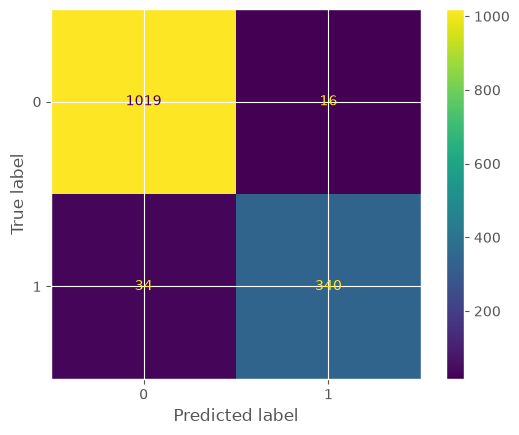

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

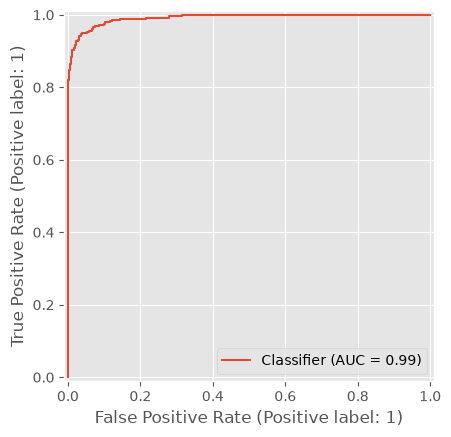

In [29]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

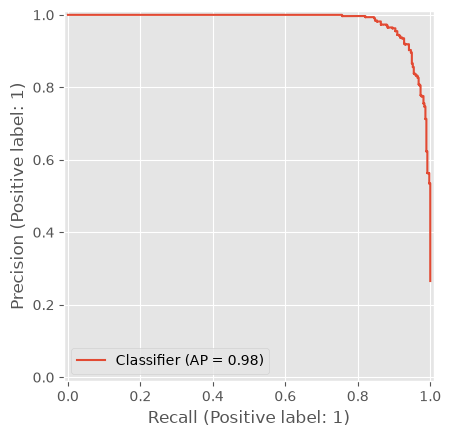

In [30]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_prob)

In [31]:
import joblib

joblib.dump(soft_voting, "../models/soft_voting.pkl")

['../models/soft_voting.pkl']